In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("..")
print("at directory:", os.getcwd())

at directory: /Users/wilka/git/research/human-dyna-web/analysis_notebooks
changing to root directory
at directory: /Users/wilka/git/research/human-dyna-web


In [3]:
import polars as pl
import jax

from analysis import housemaze_model_data
from analysis import housemaze_analysis

# env, example_timestep = housemaze_model_data.load_env_and_example_timestep()

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl


In [103]:
data_dir = "/Users/wilka/git/research/results/human_dyna"
path = f"usfa/save_data/usfa-big-10-search/sf_h=1024,num_=2,tota=40000000,exp=exp2"
paths = f"{data_dir}/model_data/{path}/seed=*"
# import glob
# print(glob.glob(paths))

sf_df = housemaze_model_data.get_usfa_data(
  paths, num_episodes=3, overwrite_episodes=True, overwrite_df=True, vis_coeff=0.01
)
sf_df["task"].unique()

  0%|          | 0/1 [00:00<?, ?it/s]

No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy


usfa: Generating maze episodes:   0%|          | 0/6 [00:00<?, ?it/s]

usfa: Generating maze information:   0%|          | 0/6 [00:00<?, ?it/s]

task
i64
26
40


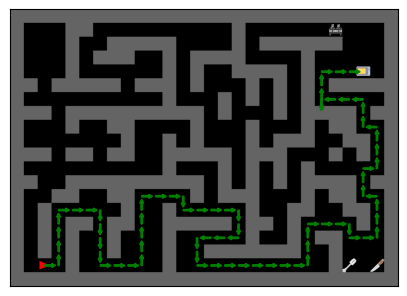

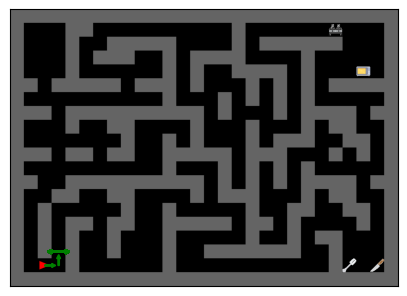

In [104]:
from analysis import housemaze_utils

housemaze_utils.render_path(
  sf_df.filter(eval=False, seed=1, manipulation=3, task=26).episodes[0]
)
housemaze_utils.render_path(
  sf_df.filter(eval=True, seed=1, manipulation=3, task=40).episodes[0]
)

In [13]:
all_sf_values = subset.transitions.extras[
  "preds"
].sf  # Get full SF values to determine shape
all_sf_values.shape

(80, 2, 4, 8)

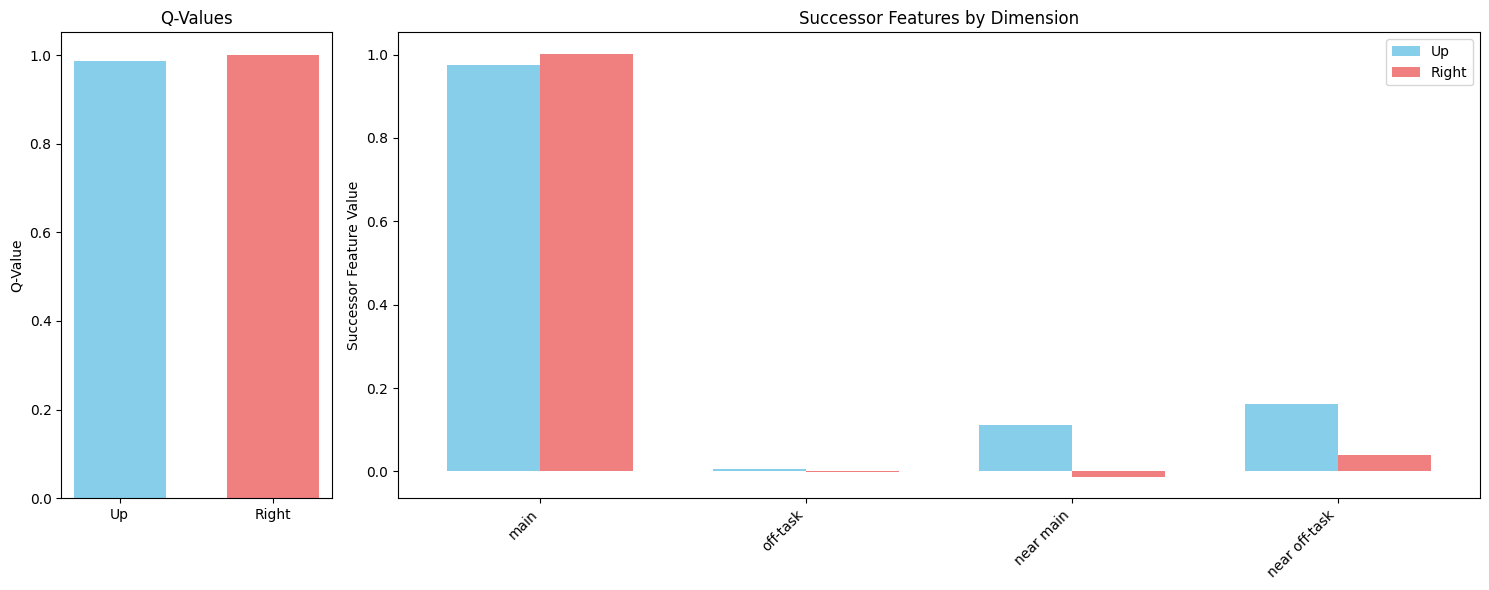

In [26]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np


def plot_action_sfs(up_sf, right_sf, task_w, line_mask=None, line_names=None):
  """
  Plot a comparison of successor features for up and right actions.

  Args:
      up_sf: Successor features for up action (vector of length 8)
      right_sf: Successor features for right action (vector of length 8)
      task_w: Task weights for Q-value computation (vector of length 8)
      line_mask: Boolean mask for which features to show (length 8)
      line_names: Names for each feature dimension (length 8)
  """
  if line_mask is None:
    line_mask = [True, True, False, False, True, True, False, False]

  if line_names is None:
    line_names = [
      "main",
      "off-task",
      "main2",
      "off-task2",
      "near main",
      "near off-task",
      "near-main2",
      "near-off-task2",
    ]

  # Calculate Q-values
  q_up = float(jnp.dot(task_w, up_sf))
  q_right = float(jnp.dot(task_w, right_sf))

  # Get masked values and names
  masked_indices = jnp.array(line_mask)
  masked_up = up_sf[masked_indices]
  masked_right = right_sf[masked_indices]
  masked_names = [name for name, mask in zip(line_names, line_mask) if mask]

  # Set up the plot with two subplots side by side
  fig, (ax_q, ax_sf) = plt.subplots(
    1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1, 4]}
  )

  # Plot Q-values on the left subplot
  bar_width = 0.6
  ax_q.bar(["Up"], [q_up], bar_width, color="skyblue", label="Up")
  ax_q.bar(["Right"], [q_right], bar_width, color="lightcoral", label="Right")
  ax_q.set_ylabel("Q-Value")
  ax_q.set_title("Q-Values")

  # Number of features for the right subplot
  n_features = len(masked_names)

  # Set positions for SF bars
  bar_width = 0.35
  r1 = np.arange(n_features)
  r2 = [x + bar_width for x in r1]

  # Create SF bars
  ax_sf.bar(r1, masked_up, bar_width, label="Up", color="skyblue")
  ax_sf.bar(r2, masked_right, bar_width, label="Right", color="lightcoral")

  # Customize the SF plot
  ax_sf.set_ylabel("Successor Feature Value")
  ax_sf.set_title("Successor Features by Dimension")
  ax_sf.set_xticks([r + bar_width / 2 for r in range(n_features)])
  ax_sf.set_xticklabels(masked_names, rotation=45, ha="right")

  # Add legend to SF plot
  ax_sf.legend()

  # Adjust layout to prevent label cutoff
  plt.tight_layout()

  return fig, (ax_q, ax_sf)


# Example usage:
fig, (ax_q, ax_sf) = plot_action_sfs(up_sf, right_sf, task_w)
# plt.show()

In [70]:
from housemaze.env import KeyboardActions
from housemaze.human_dyna import mazes
from housemaze.human_dyna import sf_task_runner

num_groups = 2
char2idx, groups, task_objects = mazes.get_group_set(num_groups)
task_objects = groups.reshape(-1)
task_runner_sf = sf_task_runner.TaskRunner(
  task_objects=task_objects, vis_coeff=0.3, radius=5
)

up_sf = all_sf_values[:, 0, KeyboardActions.up]
right_sf = all_sf_values[:, 0, KeyboardActions.right]
test_task_w = task_runner_sf.task_vector(task_objects[1])
up_sf.shape, right_sf.shape, task_w.shape

No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy


((80, 8), (80, 8), (8,))

  0%|          | 0/1 [00:00<?, ?it/s]

No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy


usfa: Generating maze episodes:   0%|          | 0/6 [00:00<?, ?it/s]

usfa: Generating maze information:   0%|          | 0/6 [00:00<?, ?it/s]

[0.   1.   0.   0.   0.   0.01 0.   0.  ]


...

  0%|          | 0/1 [00:00<?, ?it/s]

No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy


usfa: Generating maze episodes:   0%|          | 0/6 [00:00<?, ?it/s]

usfa: Generating maze information:   0%|          | 0/6 [00:00<?, ?it/s]

[0.  1.  0.  0.  0.  0.2 0.  0. ]


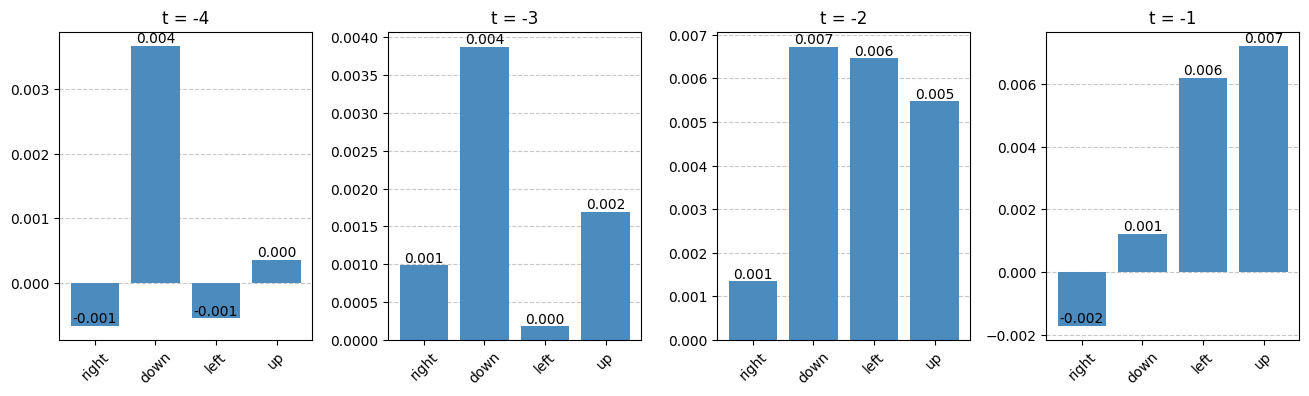

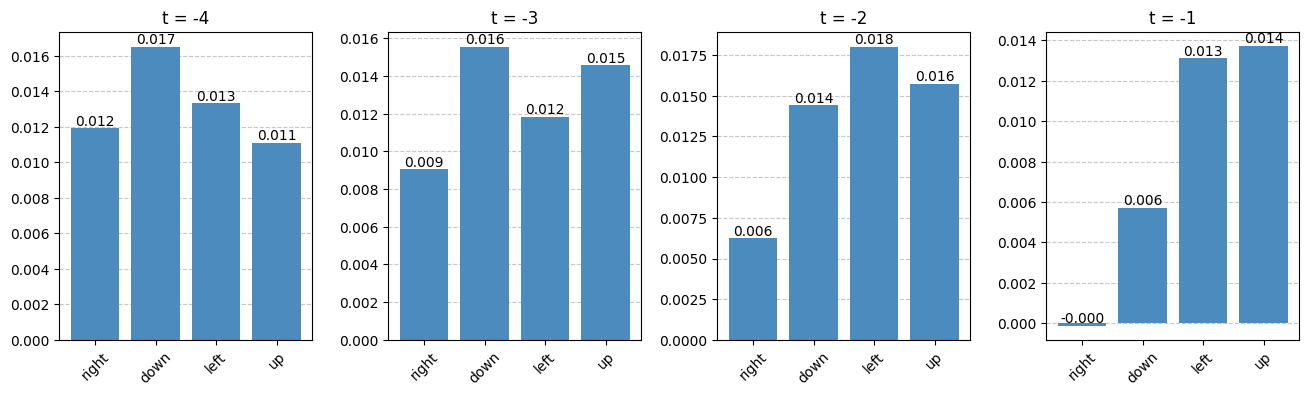

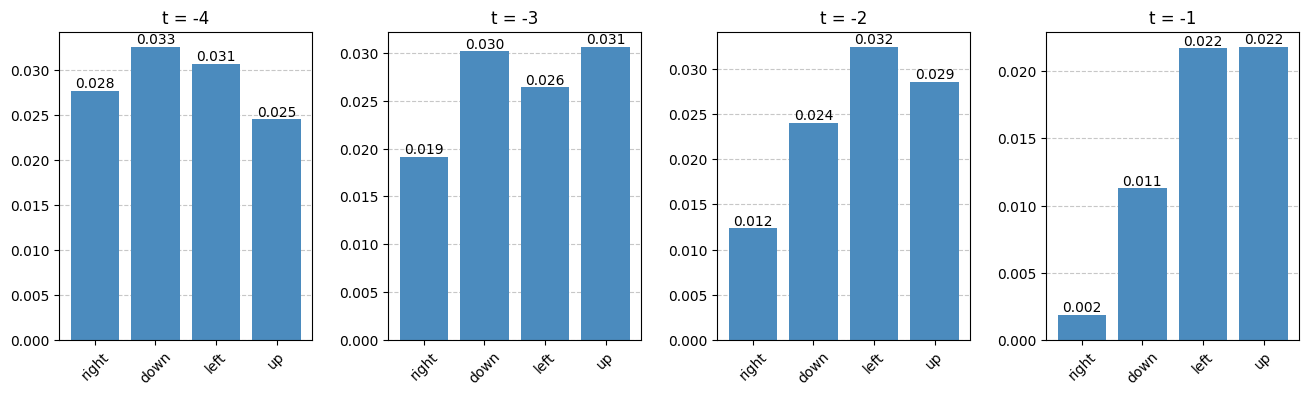

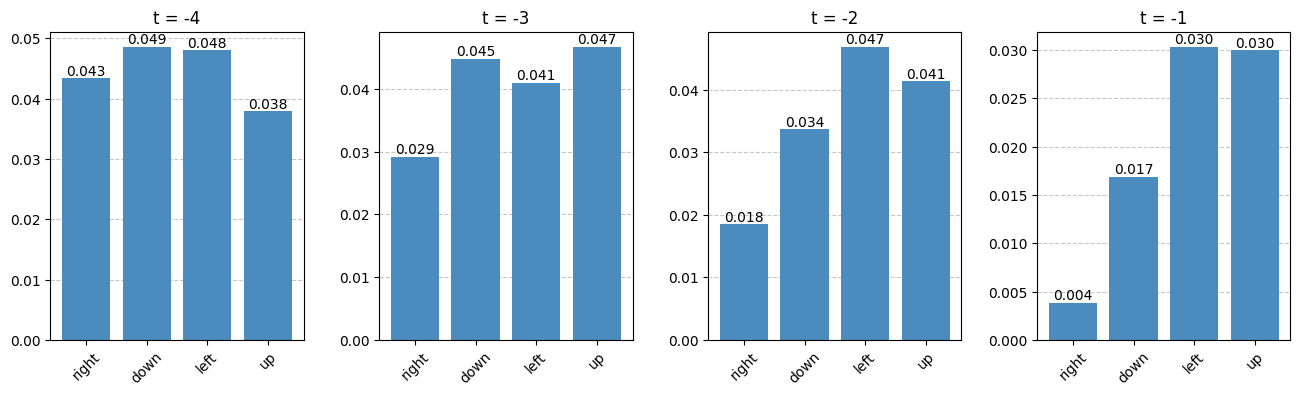

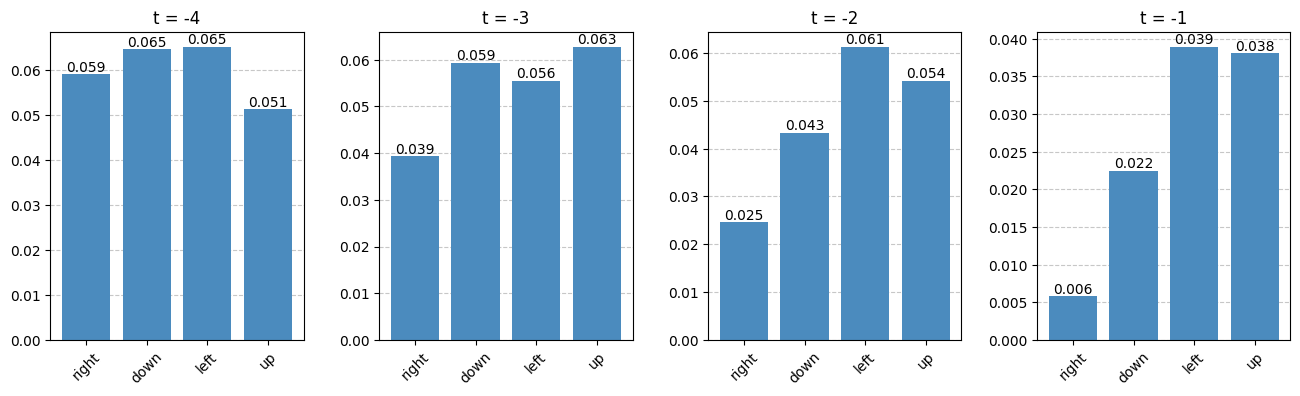

In [105]:
import numpy as np
import matplotlib.pyplot as plt


def plot_q_value_grid(all_sf_values, task_w, n_steps=4, bar_color="#4B8BBE"):
  """
  Plot a single row of Q-value bar charts, with most recent timestep on the right.

  Args:
      all_sf_values: SF values array
      test_task_w: Task weights
      n_steps: Number of time steps to plot (default: 4)
      bar_color: Color for the bars (default: Python blue)
  """
  fig, axs = plt.subplots(1, n_steps, figsize=(4 * n_steps, 4))

  # Add some padding between subplots
  plt.subplots_adjust(wspace=0.3)
  print(task_w)
  for i in range(n_steps):
    # Calculate position from right to left
    plot_idx = n_steps - i - 1

    # Calculate Q-values
    q_values = (all_sf_values[-i - 1, 0] * task_w).sum(-1)

    # Create bars
    bars = axs[plot_idx].bar(
      np.arange(len(q_values)),
      q_values,
      tick_label=["right", "down", "left", "up"],
      color=bar_color,
    )

    # Add value labels on top of bars
    for bar in bars:
      height = bar.get_height()
      axs[plot_idx].text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom",
      )

    # Customize appearance
    axs[plot_idx].set_title(f"t = -{i + 1}")
    axs[plot_idx].grid(True, axis="y", linestyle="--", alpha=0.7)
    axs[plot_idx].set_axisbelow(True)  # Put grid behind bars

    # Make y-axis symmetric around 0
    y_max = max(abs(axs[plot_idx].get_ylim()[0]), abs(axs[plot_idx].get_ylim()[1]))
    # axs[plot_idx].set_ylim(-y_max, y_max)

    # Rotate x-labels for better readability
    plt.setp(axs[plot_idx].get_xticklabels(), rotation=45)

  return fig, axs


# Example usage:
for vis_coeff in [0.01, 0.05, 0.1, 0.15, 0.2]:
  sf_df = housemaze_model_data.get_usfa_data(
    paths,
    num_episodes=1,
    overwrite_episodes=True,
    overwrite_df=True,
    vis_coeff=vis_coeff,
  )
  train_episode = sf_df.filter(eval=False, seed=1, manipulation=3).episodes[0]
  test_episode = sf_df.filter(eval=True, seed=1, manipulation=3).episodes[0]
  task_runner_sf = sf_task_runner.TaskRunner(
    task_objects=task_objects, vis_coeff=vis_coeff, radius=5
  )
  test_task_w = task_runner_sf.task_vector(task_objects[1])

  train_sf_values = subset.transitions.extras["preds"].sf
  fig = plot_q_value_grid(train_sf_values, test_task_w)
  plt.show()

[1.  0.  0.  0.  0.1 0.  0.  0. ]


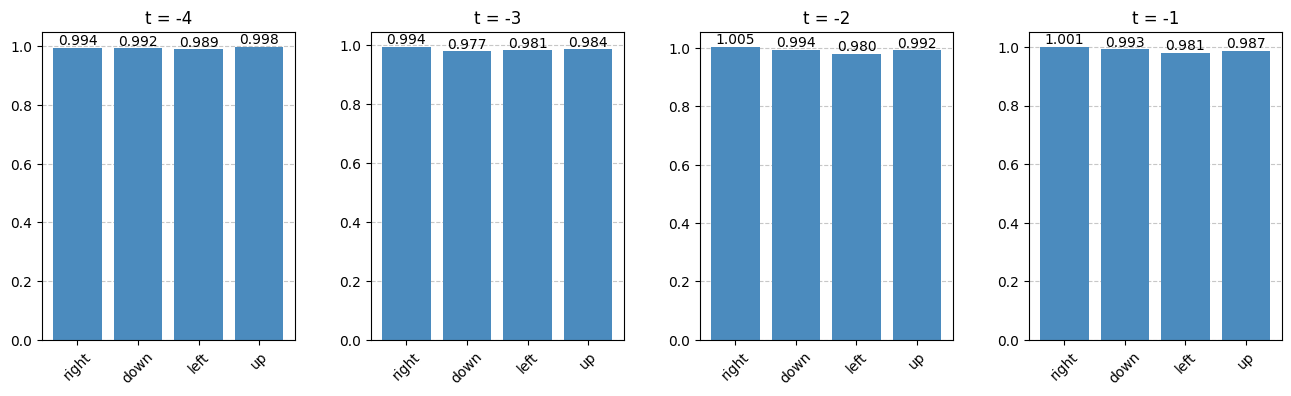

In [83]:
task_runner_sf = sf_task_runner.TaskRunner(
  task_objects=task_objects, vis_coeff=0.1, radius=5
)
train_task_w = task_runner_sf.task_vector(task_objects[0])
fig = plot_q_value_grid(all_sf_values, train_task_w)

(<Figure size 1400x500 with 2 Axes>,
 array([<Axes: title={'center': 'Successor Feature Predictions (task=main)'}, xlabel='Time Step', ylabel='Value'>,
        <Axes: title={'center': 'Successor Feature Predictions (task=main2)'}, xlabel='Time Step', ylabel='Value'>],
       dtype=object))

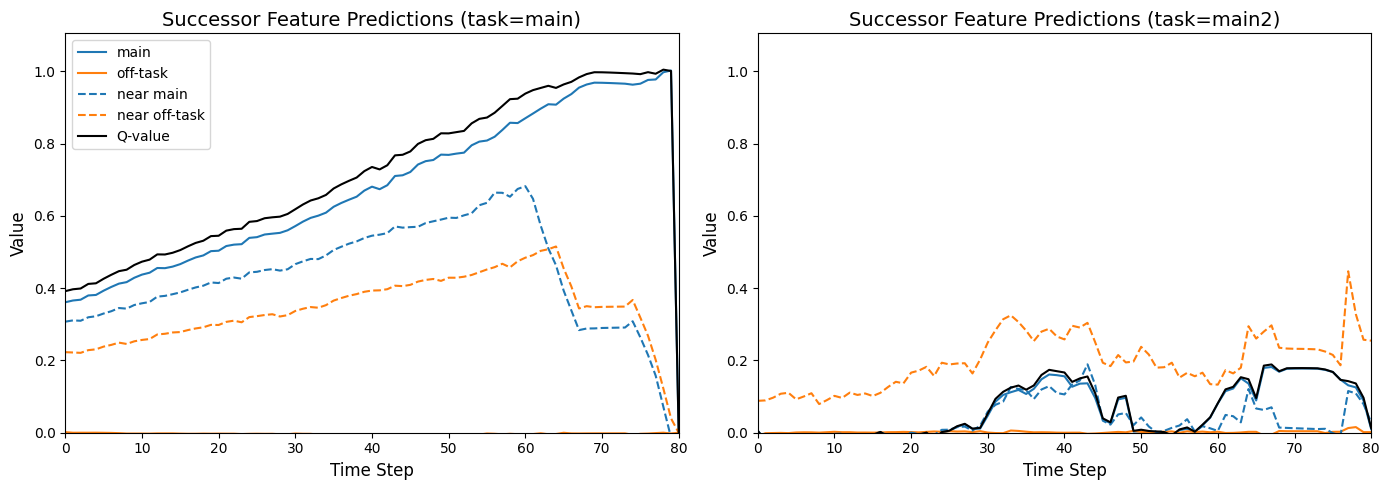

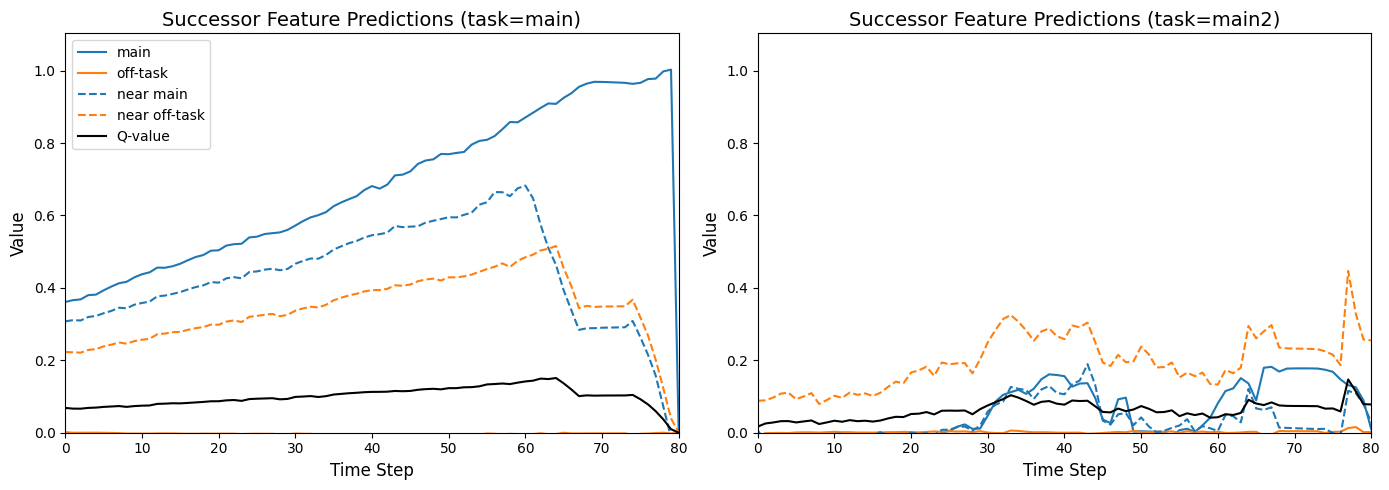

In [88]:
task_runner_sf = sf_task_runner.TaskRunner(
  task_objects=task_objects, vis_coeff=0.3, radius=5
)
test_task_w = task_runner_sf.task_vector(task_objects[1])
housemaze_analysis.plot_sf_values(testing.episodes[0], task_w=train_task_w)
housemaze_analysis.plot_sf_values(testing.episodes[0], task_w=test_task_w)

(<Figure size 500x400 with 1 Axes>,
 [<Axes: title={'center': 'Successor Feature Predictions'}, xlabel='Time Step', ylabel='Value'>])

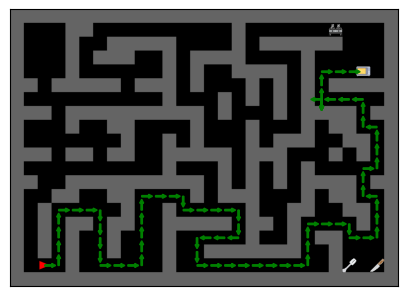

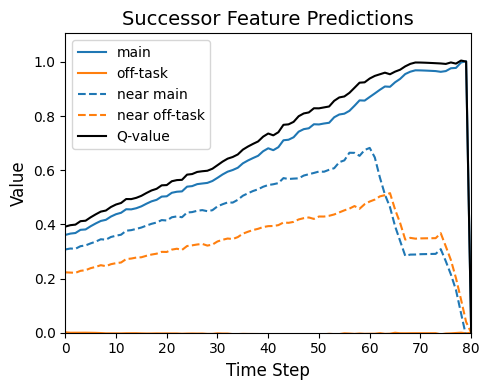

In [37]:
housemaze_utils.render_path(testing.episodes[0])
housemaze_analysis.plot_sf_values(testing.episodes[0], figsize=(5, 4), idxs=[0])